# Base vs LoRA Fine-Tuned Model Evaluation

This notebook evaluates the base Llama 3.1 8B model against the LoRA fine-tuned version using:
- 1000 random samples from the Alpaca dataset
- GPT-4o as an impartial judge (binary YES/NO scoring)
- Throughput measurement (tokens/sec) for both models

**Prerequisites:**
- Both vLLM servers running via `./scripts/serve_k8s.sh`
- `pip install openai datasets matplotlib seaborn pandas`

**Parameters (prompted on run):**
- `BASE_IP` — LoadBalancer IP of the base model vLLM server
- `LORA_IP` — LoadBalancer IP of the LoRA model vLLM server
- `OPENAI_API_KEY` — OpenAI API key for GPT-4o judge

You can also set these as environment variables before launching Jupyter to skip the prompts.

In [1]:
!pip install -q openai datasets matplotlib seaborn pandas

zsh:1: /Users/behnam/workspace/nebius-tasks/training-task/.venv/bin/pip: bad interpreter: /Users/behnam/workspace/nebius-tasks/training-task/venv/bin/python3.14: no such file or directory


## 1. Configuration

In [2]:
import os

# Prompt for required parameters
BASE_IP = os.environ.get("BASE_IP") or input("Base model LoadBalancer IP: ").strip()
LORA_IP = os.environ.get("LORA_IP") or input("LoRA model LoadBalancer IP: ").strip()
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY") or input("OpenAI API key: ").strip()
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

BASE_URL = f"http://{BASE_IP}:8000"
LORA_URL = f"http://{LORA_IP}:8000"

BASE_MODEL_NAME = "/mnt/data/Llama-3.1-8B"
LORA_MODEL_NAME = "lora-adapter"

NUM_SAMPLES = 1000
MAX_TOKENS = 512
TEMPERATURE = 0.1
SEED = 42
PARALLEL_WORKERS = 8

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Base URL: {BASE_URL}")
print(f"LoRA URL: {LORA_URL}")
print(f"Samples:  {NUM_SAMPLES}")

Base URL: http://89.169.113.193:8000
LoRA URL: http://89.169.122.10:8000
Samples:  1000


## 2. Load and Sample Dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset("tatsu-lab/alpaca", split="train")
dataset = dataset.shuffle(seed=SEED).select(range(NUM_SAMPLES))
samples = list(dataset)

print(f"Loaded {len(samples)} samples from Alpaca dataset")
print(f"\nExample:")
print(f"  Instruction: {samples[0]['instruction'][:100]}...")
print(f"  Input:       {samples[0].get('input', '')[:100]}")
print(f"  Output:      {samples[0]['output'][:100]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Loaded 1000 samples from Alpaca dataset

Example:
  Instruction: What would be the best type of exercise for a person who has arthritis?...
  Input:       
  Output:      For someone with arthritis, the best type of exercise would be low-impact activities like yoga, swim...


## 3. Query Both Models

In [4]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI

base_client = OpenAI(api_key="EMPTY", base_url=f"{BASE_URL}/v1")
lora_client = OpenAI(api_key="EMPTY", base_url=f"{LORA_URL}/v1")


def format_prompt(instruction, input_text=""):
    if input_text:
        return f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n"
    return f"### Instruction:\n{instruction}\n\n### Response:\n"


def query_model(client, model_name, instruction, input_text=""):
    prompt = format_prompt(instruction, input_text)
    start = time.time()
    response = client.completions.create(
        model=model_name,
        prompt=prompt,
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    elapsed = time.time() - start
    text = response.choices[0].text.strip()
    tokens = response.usage.completion_tokens
    return text, elapsed, tokens


def query_sample(i, sample):
    instruction = sample["instruction"]
    input_text = sample.get("input", "") or ""
    result = {
        "index": i,
        "instruction": instruction,
        "input": input_text,
        "expected": sample.get("output", ""),
    }
    try:
        text, elapsed, tokens = query_model(base_client, BASE_MODEL_NAME, instruction, input_text)
        result["base_response"] = text
        result["base_time"] = elapsed
        result["base_tokens"] = tokens
    except Exception as e:
        result["base_response"] = ""
        result["base_time"] = 0
        result["base_tokens"] = 0
        result["base_error"] = str(e)

    try:
        text, elapsed, tokens = query_model(lora_client, LORA_MODEL_NAME, instruction, input_text)
        result["lora_response"] = text
        result["lora_time"] = elapsed
        result["lora_tokens"] = tokens
    except Exception as e:
        result["lora_response"] = ""
        result["lora_time"] = 0
        result["lora_tokens"] = 0
        result["lora_error"] = str(e)

    return result

In [5]:
print(f"Querying both models with {NUM_SAMPLES} samples ({PARALLEL_WORKERS} workers)...\n")

results = []
start_time = time.time()

with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
    futures = {executor.submit(query_sample, i, s): i for i, s in enumerate(samples)}
    for future in as_completed(futures):
        result = future.result()
        results.append(result)
        done = len(results)
        if done % 100 == 0 or done == NUM_SAMPLES:
            elapsed = time.time() - start_time
            print(f"  [{done:4d}/{NUM_SAMPLES}] {elapsed:.0f}s elapsed, {done/elapsed:.1f} samples/s")

results.sort(key=lambda x: x["index"])
total_query_time = time.time() - start_time
print(f"\nDone. Total query time: {total_query_time:.1f}s")

Querying both models with 1000 samples (8 workers)...

  [ 100/1000] 82s elapsed, 1.2 samples/s
  [ 200/1000] 166s elapsed, 1.2 samples/s
  [ 300/1000] 248s elapsed, 1.2 samples/s
  [ 400/1000] 339s elapsed, 1.2 samples/s
  [ 500/1000] 427s elapsed, 1.2 samples/s
  [ 600/1000] 521s elapsed, 1.2 samples/s
  [ 700/1000] 615s elapsed, 1.1 samples/s
  [ 800/1000] 705s elapsed, 1.1 samples/s
  [ 900/1000] 798s elapsed, 1.1 samples/s
  [1000/1000] 902s elapsed, 1.1 samples/s

Done. Total query time: 901.8s


## 4. GPT-4o Judge

In [6]:
judge_client = OpenAI()

JUDGE_SYSTEM = """You are an impartial judge evaluating AI model responses.
Given an instruction (and optional input) and the model's response, decide whether
the response is correct, relevant, and helpful.

Rules:
- Answer ONLY "YES" or "NO".
- YES means the response correctly addresses the instruction, is factually reasonable,
  and provides a useful answer.
- NO means the response is wrong, irrelevant, incomplete, or nonsensical."""

JUDGE_TEMPLATE = """### Instruction:
{instruction}

{input_section}### Model Response:
{response}

Is this response correct, relevant, and helpful? Answer YES or NO."""


def judge_response(instruction, input_text, response):
    if not response:
        return 0
    input_section = f"### Input:\n{input_text}\n\n" if input_text else ""
    user_msg = JUDGE_TEMPLATE.format(
        instruction=instruction,
        input_section=input_section,
        response=response,
    )
    result = judge_client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": user_msg},
        ],
        max_tokens=5,
        temperature=0,
    )
    answer = result.choices[0].message.content.strip().upper()
    return 1 if answer.startswith("YES") else 0


def judge_sample(result):
    result["base_score"] = judge_response(
        result["instruction"], result["input"], result.get("base_response", "")
    )
    result["lora_score"] = judge_response(
        result["instruction"], result["input"], result.get("lora_response", "")
    )
    return result

In [7]:
print(f"Judging {len(results)} samples with GPT-4o ({PARALLEL_WORKERS} workers)...\n")

judged_results = []
start_time = time.time()

with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
    futures = {executor.submit(judge_sample, r): r["index"] for r in results}
    for future in as_completed(futures):
        judged_results.append(future.result())
        done = len(judged_results)
        if done % 100 == 0 or done == len(results):
            elapsed = time.time() - start_time
            base_acc = sum(r["base_score"] for r in judged_results) / done * 100
            lora_acc = sum(r["lora_score"] for r in judged_results) / done * 100
            print(f"  [{done:4d}/{len(results)}] Base: {base_acc:.1f}% | LoRA: {lora_acc:.1f}% | {elapsed:.0f}s")

judged_results.sort(key=lambda x: x["index"])
total_judge_time = time.time() - start_time
print(f"\nJudging complete. Time: {total_judge_time:.1f}s")

Judging 1000 samples with GPT-4o (8 workers)...



RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-ulZwXqExogzqTkuVOUTiN5KO on tokens per min (TPM): Limit 30000, Used 30000, Requested 164. Please try again in 328ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

## 5. Save Results

In [8]:
import json
import pandas as pd

df = pd.DataFrame(judged_results)

# Save detailed results
df.to_csv(f"{RESULTS_DIR}/eval_details.csv", index=False)
df.to_json(f"{RESULTS_DIR}/eval_details.json", orient="records", indent=2)

# Save summary
summary = {
    "num_samples": len(df),
    "base_accuracy": round(df["base_score"].mean() * 100, 2),
    "lora_accuracy": round(df["lora_score"].mean() * 100, 2),
    "improvement": round((df["lora_score"].mean() - df["base_score"].mean()) * 100, 2),
    "base_avg_tokens": round(df["base_tokens"].mean(), 1),
    "lora_avg_tokens": round(df["lora_tokens"].mean(), 1),
    "base_avg_latency_s": round(df["base_time"].mean(), 3),
    "lora_avg_latency_s": round(df["lora_time"].mean(), 3),
    "base_throughput_tok_s": round(df["base_tokens"].sum() / df["base_time"].sum(), 1),
    "lora_throughput_tok_s": round(df["lora_tokens"].sum() / df["lora_time"].sum(), 1),
}

with open(f"{RESULTS_DIR}/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to results/:")
print(f"  eval_details.csv   ({len(df)} rows)")
print(f"  eval_details.json  ({len(df)} records)")
print(f"  eval_summary.json")
print(f"\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

Saved to results/:
  eval_details.csv   (64 rows)
  eval_details.json  (64 records)
  eval_summary.json

Summary:
  num_samples: 64
  base_accuracy: 51.56
  lora_accuracy: 87.5
  improvement: 35.94
  base_avg_tokens: 224.5
  lora_avg_tokens: 52.0
  base_avg_latency_s: 5.55
  lora_avg_latency_s: 1.403
  base_throughput_tok_s: 40.4
  lora_throughput_tok_s: 37.0


## 6. Accuracy Analysis

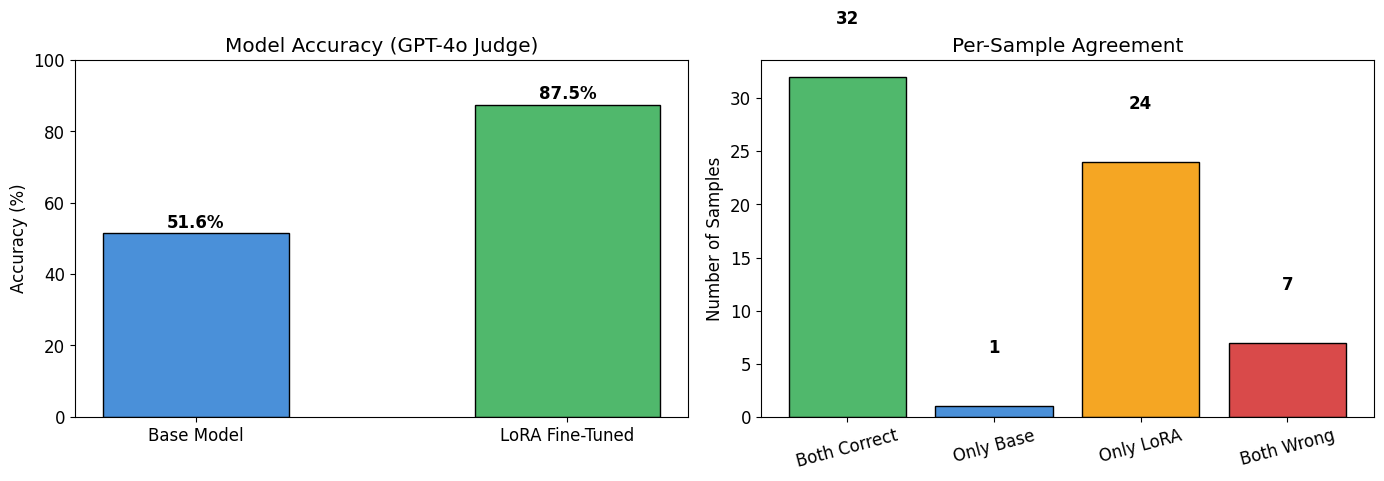

Saved: results/accuracy_comparison.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

base_acc = df["base_score"].mean() * 100
lora_acc = df["lora_score"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy comparison
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_acc, lora_acc],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy (GPT-4o Judge)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, [base_acc, lora_acc]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# Stacked bar: per-sample agreement
both_correct = ((df["base_score"] == 1) & (df["lora_score"] == 1)).sum()
only_base = ((df["base_score"] == 1) & (df["lora_score"] == 0)).sum()
only_lora = ((df["base_score"] == 0) & (df["lora_score"] == 1)).sum()
both_wrong = ((df["base_score"] == 0) & (df["lora_score"] == 0)).sum()

categories = ["Both Correct", "Only Base", "Only LoRA", "Both Wrong"]
values = [both_correct, only_base, only_lora, both_wrong]
colors = ["#50b86c", "#4a90d9", "#f5a623", "#d94a4a"]

bars2 = axes[1].bar(categories, values, color=colors, edgecolor="black")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Per-Sample Agreement")
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/accuracy_comparison.png")

## 7. Confusion Matrix

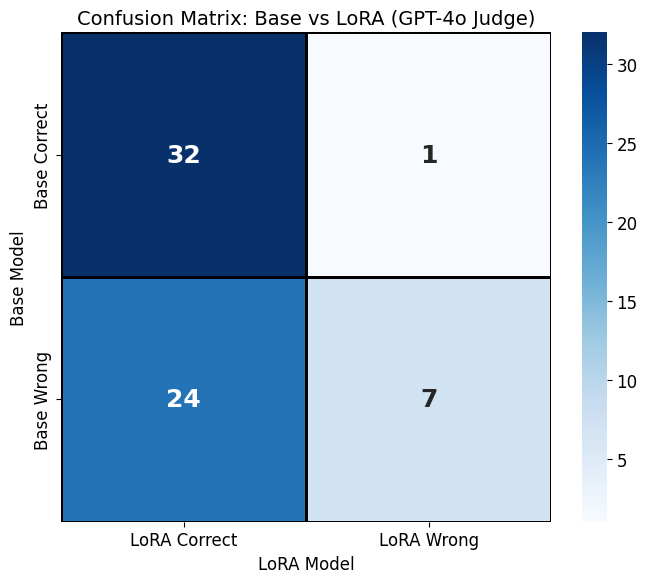

Saved: results/confusion_matrix.png

Interpretation:
  Both correct:         32 (50.0%)
  Only base correct:     1 (1.6%) — LoRA regression
  Only LoRA correct:    24 (37.5%) — LoRA improvement
  Both wrong:            7 (10.9%)


In [10]:
import seaborn as sns
import numpy as np

confusion = np.array([
    [both_correct, only_base],
    [only_lora, both_wrong],
])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["LoRA Correct", "LoRA Wrong"],
    yticklabels=["Base Correct", "Base Wrong"],
    linewidths=1,
    linecolor="black",
    annot_kws={"size": 18, "fontweight": "bold"},
    ax=ax,
)
ax.set_title("Confusion Matrix: Base vs LoRA (GPT-4o Judge)", fontsize=14)
ax.set_xlabel("LoRA Model", fontsize=12)
ax.set_ylabel("Base Model", fontsize=12)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/confusion_matrix.png")
print(f"\nInterpretation:")
print(f"  Both correct:       {both_correct:4d} ({both_correct/len(df)*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/len(df)*100:.1f}%) — LoRA regression")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/len(df)*100:.1f}%) — LoRA improvement")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/len(df)*100:.1f}%)")

## 8. Throughput Analysis

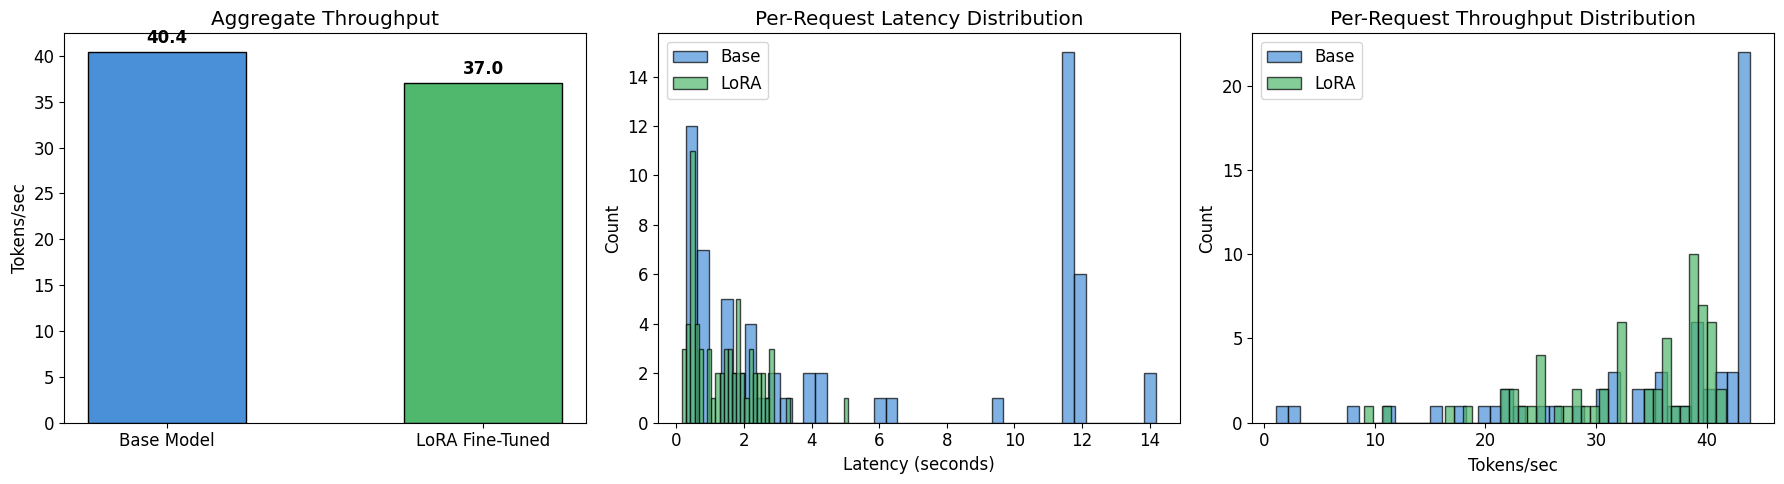

Saved: results/throughput_analysis.png

Throughput Summary:
  Base:  40.4 tok/s (avg latency: 5.550s, p95: 11.795s)
  LoRA:  37.0 tok/s (avg latency: 1.403s, p95: 2.831s)
  Overhead: -8.4% throughput change with LoRA


In [11]:
base_tok_s = df["base_tokens"].sum() / df["base_time"].sum()
lora_tok_s = df["lora_tokens"].sum() / df["lora_time"].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Throughput bar chart
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_tok_s, lora_tok_s],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Tokens/sec")
axes[0].set_title("Aggregate Throughput")
for bar, val in zip(bars, [base_tok_s, lora_tok_s]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}", ha="center", fontweight="bold")

# Latency distribution
axes[1].hist(df["base_time"], bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[1].hist(df["lora_time"], bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[1].set_xlabel("Latency (seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Request Latency Distribution")
axes[1].legend()

# Per-request throughput (tokens/sec)
base_per_req = df["base_tokens"] / df["base_time"].replace(0, float("nan"))
lora_per_req = df["lora_tokens"] / df["lora_time"].replace(0, float("nan"))
axes[2].hist(base_per_req.dropna(), bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[2].hist(lora_per_req.dropna(), bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[2].set_xlabel("Tokens/sec")
axes[2].set_ylabel("Count")
axes[2].set_title("Per-Request Throughput Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/throughput_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/throughput_analysis.png")
print(f"\nThroughput Summary:")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg latency: {df['base_time'].mean():.3f}s, p95: {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg latency: {df['lora_time'].mean():.3f}s, p95: {df['lora_time'].quantile(0.95):.3f}s)")
print(f"  Overhead: {(lora_tok_s/base_tok_s - 1)*100:+.1f}% throughput change with LoRA")

## 9. Summary Report

In [12]:
print("=" * 60)
print("EVALUATION REPORT")
print("=" * 60)
print(f"")
print(f"Dataset:     Alpaca ({NUM_SAMPLES} samples, seed={SEED})")
print(f"Judge:       GPT-4o (binary YES/NO)")
print(f"Base Model:  Llama 3.1 8B")
print(f"LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)")
print(f"")
print(f"--- Accuracy ---")
print(f"  Base:        {base_acc:.1f}%")
print(f"  LoRA:        {lora_acc:.1f}%")
print(f"  Improvement: {lora_acc - base_acc:+.1f}%")
print(f"")
print(f"--- Agreement ---")
print(f"  Both correct:       {both_correct:4d} ({both_correct/len(df)*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/len(df)*100:.1f}%)")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/len(df)*100:.1f}%)")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/len(df)*100:.1f}%)")
print(f"")
print(f"--- Throughput ---")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg {df['base_time'].mean():.3f}s, p95 {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg {df['lora_time'].mean():.3f}s, p95 {df['lora_time'].quantile(0.95):.3f}s)")
print(f"")
print(f"--- Output Files ---")
print(f"  {RESULTS_DIR}/eval_details.csv")
print(f"  {RESULTS_DIR}/eval_details.json")
print(f"  {RESULTS_DIR}/eval_summary.json")
print(f"  {RESULTS_DIR}/accuracy_comparison.png")
print(f"  {RESULTS_DIR}/confusion_matrix.png")
print(f"  {RESULTS_DIR}/throughput_analysis.png")
print("=" * 60)

EVALUATION REPORT

Dataset:     Alpaca (1000 samples, seed=42)
Judge:       GPT-4o (binary YES/NO)
Base Model:  Llama 3.1 8B
LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)

--- Accuracy ---
  Base:        51.6%
  LoRA:        87.5%
  Improvement: +35.9%

--- Agreement ---
  Both correct:         32 (50.0%)
  Only base correct:     1 (1.6%)
  Only LoRA correct:    24 (37.5%)
  Both wrong:            7 (10.9%)

--- Throughput ---
  Base:  40.4 tok/s (avg 5.550s, p95 11.795s)
  LoRA:  37.0 tok/s (avg 1.403s, p95 2.831s)

--- Output Files ---
  results/eval_details.csv
  results/eval_details.json
  results/eval_summary.json
  results/accuracy_comparison.png
  results/confusion_matrix.png
  results/throughput_analysis.png
